In [ ]:
# import libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
#reading the different excel sheets.
df_1 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Line productivity')
df_2 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Products')
df_3 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Downtime factors')
df_4 = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Line downtime')
#df_4_nice = pd.read_excel('/Users/nataliastroher/NatisProjects/manufacturing_downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Line downtime', header=0, skiprows=[0])

In [163]:
# reading the dataframes to check the correctness of the data and columns.
#df_1.head()
#df_2.head()
#df_3.head()
#df_4_nice.head()

In [164]:
# Providing new meaningful column names to df_4 (line downtime); instead of Factors 1 to 12, the actual names, taken out of df_3.
df_4_clean = df_4.copy()

df_4_clean.columns = df_4_clean.iloc[0]
df_4_clean = df_4_clean.iloc[1:].reset_index(drop=True)

# 2. Faktor-Mapping aus df_3 erstellen
factor_map = dict(zip(df_3["Factor"], df_3["Description"]))

# 3. Spaltennamen vorbereiten und umbenennen
new_columns = []

for col in df_4_clean.columns:
    # Batch-Spalte behalten
    if col == "Batch":
        new_columns.append("Batch")
    else:
        # aus 1.0 -> 1 machen
        factor_number = int(float(col))
        new_columns.append(factor_map[factor_number])

df_4_clean.columns = new_columns

# 4. Werte numerisch machen, außer Batch
for col in df_4_clean.columns:
    if col != "Batch":
        df_4_clean[col] = pd.to_numeric(df_4_clean[col], errors="coerce")

#df_4_clean.head()

In [165]:
#downtime per batch
df_4_clean["Total_Downtime"] = df_4_clean.drop(columns="Batch").sum(axis=1)
#df_4_clean.head()

In [166]:
# adding the total downtime per batch to the main dataframe.
df_1['Total_Downtime'] = df_4_clean['Total_Downtime']

In [167]:
#df_1.head()

In [168]:
#df_1.info()

/var/folders/3y/f9tt7gts7qs7mbxh1h2q8x8h0000gn/T/ipykernel_9409/2294874209.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df1_grouped, x="Product", y="Total_Downtime", palette="Blues_d")


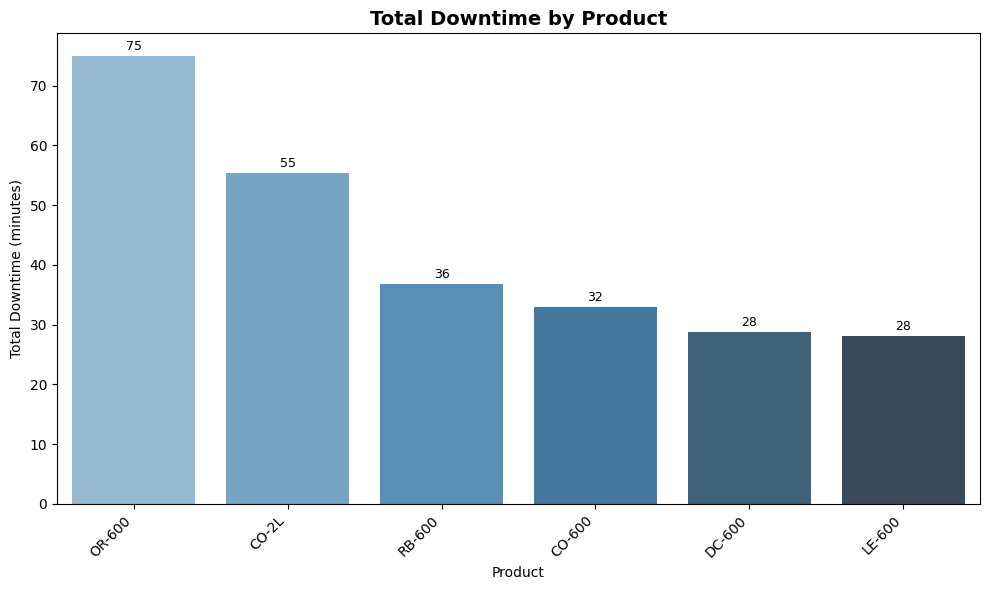

In [169]:
#1- line productivity 
df1_grouped = df_1.groupby('Product')['Total_Downtime'].mean().reset_index()
df1_grouped = df1_grouped.sort_values('Total_Downtime', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df1_grouped, x="Product", y="Total_Downtime", palette="Blues_d")

# Labels
plt.title("Total Downtime by Product", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Total Downtime (minutes)")
plt.xticks(rotation=45, ha="right")

# Add value labels on top of each bar
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{int(bar.get_height())}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()


In [170]:
# Transform from wide to long
df_long = df_4_clean.melt(
    id_vars="Batch",
    var_name="Factor",
    value_name="Minutes"
)
#df_long.head()

In [171]:
df_long = df_long.merge(df_3, left_on="Factor",right_on="Description", how="left")

In [172]:
#df_long.head()

In [173]:
# Group by Batch + Operator Error
df_result = df_long.groupby(["Batch", "Operator Error"])["Minutes"].sum().unstack(fill_value=0).reset_index()
df_result.columns.name = None
# Flatten the MultiIndex columns first
df_result.columns = ["Batch", "Human_Error_Minutes", "Machine_Error_Minutes"]



In [174]:

# Merge into main dataset
df_1 = df_1.merge(df_result, on="Batch", how="left")

#df_1.head()

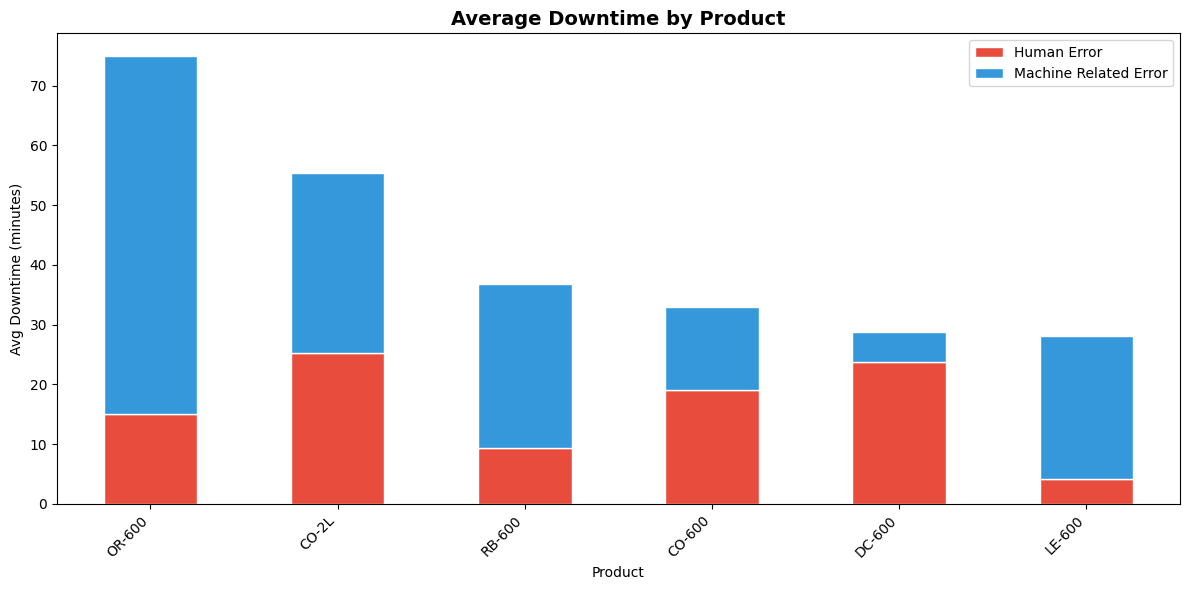

In [175]:
# Group by Product and calculate averages
df_plot = df_1.groupby("Product")[["Human_Error_Minutes", "Machine_Error_Minutes"]].mean().reset_index()
df_plot['Total'] = df_plot['Human_Error_Minutes'] + df_plot['Machine_Error_Minutes']
df_plot = df_plot.sort_values('Total', ascending=False).drop(columns='Total')

# 3. Plot stacked bar chart
ax = df_plot.set_index("Product")[["Human_Error_Minutes", "Machine_Error_Minutes"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#e74c3c", "#3498db"],  # red for human, blue for machine
    edgecolor="white"
)

plt.title("Average Downtime by Product", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Avg Downtime (minutes)")
plt.xticks(rotation=45, ha="right")
plt.legend(["Human Error", "Machine Related Error"])
plt.tight_layout()
plt.show()

In [176]:
df_plot["Human_Pct"] = df_plot["Human_Error_Minutes"] / (df_plot["Human_Error_Minutes"] + df_plot["Machine_Error_Minutes"]) * 100
df_plot["Machine_Pct"] = 100 - df_plot["Human_Pct"]

print(df_plot[["Product", "Human_Pct", "Machine_Pct"]].sort_values("Human_Pct", ascending=False))

  Product  Human_Pct  Machine_Pct
2  DC-600  82.608696    17.391304
1  CO-600  57.894737    42.105263
0   CO-2L  45.487365    54.512635
5  RB-600  25.193798    74.806202
4  OR-600  20.000000    80.000000
3  LE-600  14.792899    85.207101


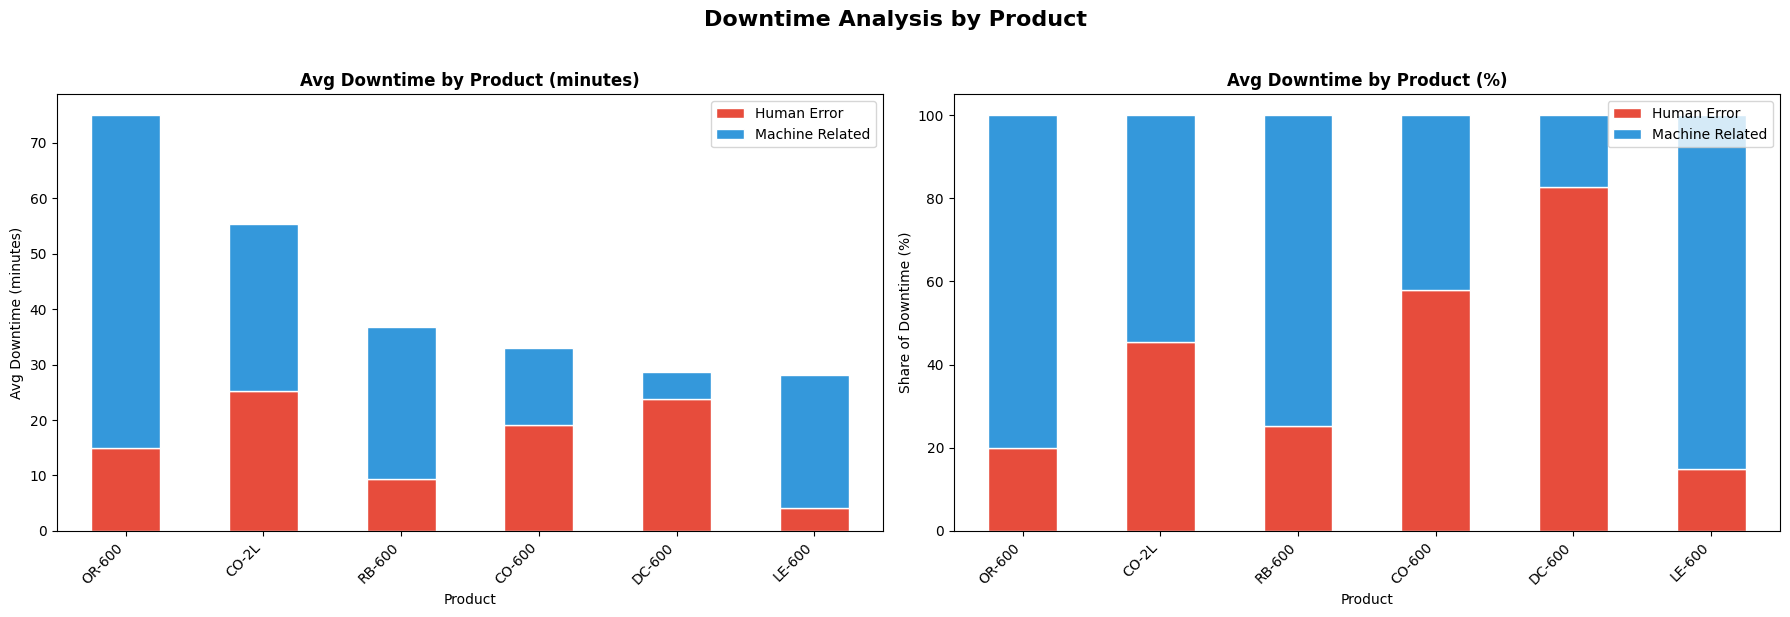

In [177]:
# Prepare absolute data (already have this)
df_abs = df_plot.copy()

# Prepare percentage data
df_pct = df_plot.copy()
df_pct["Human_Error_Minutes"] = df_plot["Human_Error_Minutes"] / (df_plot["Human_Error_Minutes"] + df_plot["Machine_Error_Minutes"]) * 100
df_pct["Machine_Error_Minutes"] = 100 - df_pct["Human_Error_Minutes"]

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Left: absolute minutes
df_abs.set_index("Product")[["Human_Error_Minutes", "Machine_Error_Minutes"]].plot(
    kind="bar", stacked=True, ax=ax1,
    color=["#e74c3c", "#3498db"], edgecolor="white"
)
ax1.set_title("Avg Downtime by Product (minutes)", fontweight="bold")
ax1.set_xlabel("Product")
ax1.set_ylabel("Avg Downtime (minutes)")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.legend(["Human Error", "Machine Related"])

# Right: percentage
df_pct.set_index("Product")[["Human_Error_Minutes", "Machine_Error_Minutes"]].plot(
    kind="bar", stacked=True, ax=ax2,
    color=["#e74c3c", "#3498db"], edgecolor="white"
)
ax2.set_title("Avg Downtime by Product (%)", fontweight="bold")
ax2.set_xlabel("Product")
ax2.set_ylabel("Share of Downtime (%)")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
ax2.legend(["Human Error", "Machine Related"])

plt.suptitle("Downtime Analysis by Product", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

3- Leading factors for downtime

Frequency — which happens more often?
Severity — which causes longer downtime per incident?